# Análise do Instance Selection (bio-IS)

Análise geral das instâncias **removidas** pelo Instance Selection (técnica `bio-is`) em 4 datasets:

| Dataset | Experimento |
|---|---|
| agnews | `2026-04-09_13-20-16 - rep1` |
| books | `2026-04-09_13-21-37` |
| dblp | `2026-04-09_14-05-21` |
| movie_review | `2026-04-09_13-17-23` |

**Objetivos**

1. Das instâncias filtradas (removidas), quantas eram realmente classificadas **erroneamente** vs **corretamente** pelas anotações dos modelos (`resolved_annotation` vs `ground_truth`).
2. Das removidas, quantas tinham **baixo consenso** (2x1 / `medium`) vs **alto consenso** (3x0 / `high`).
3. Análises extras: cruzamentos corretude × consenso × motivo de remoção, comparação removidas vs mantidas (qualidade do filtro), distribuição por classe, tamanho do texto e confiança.

> **Convenção de consenso** (3 modelos anotadores): `high` = 3x0 (unânime), `medium` = 2x1 (maioria simples).
>
> ⚠️ **As instâncias de consenso 1x1x1 (`low`, discordância total) são excluídas desta análise**, pois são removidas separadamente (como casos problemáticos) antes do Instance Selection. O universo aqui é, portanto, `mantidas + removidas (não-1x1x1)`.


## 1. Setup e carga dos dados

In [19]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = False  # sem linhas de grade no fundo

# --- localizar a raiz do repositorio (procura a pasta data/results subindo na arvore) ---
ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("ROOT:", ROOT)

# importar os nomes das classes
sys.path.insert(0, str(ROOT))
from src.config.datasets_collected import LABEL_MEANINGS


ROOT: c:\Users\gabri\Documents\GitHub\llm-annotation


In [20]:
# Experimentos analisados (dataset -> pasta do experimento)
EXPERIMENTS = {
    "agnews":       "agnews/2026-04-09_13-20-16 - rep1",
    "books":        "books/2026-04-09_13-21-37",
    "dblp":         "dblp/2026-04-09_14-05-21",
    "movie_review": "movie_review/2026-04-09_13-17-23",
}

# Instancias de baixissimo consenso (1x1x1) sao removidas separadamente -> excluidas daqui.
EXCLUDE_CONSENSUS = ["low"]

CONSENSUS_LABELS = {"high": "Alto (3x0)", "medium": "Baixo (2x1)"}
CONSENSUS_ORDER  = ["high", "medium"]
PALETTE = {"high": "#2a9d8f", "medium": "#e9c46a"}

def label_name(dataset, code):
    """Converte o codigo numerico da classe no nome legivel (fallback p/ o proprio numero)."""
    m = LABEL_MEANINGS.get(dataset, {})
    name = m.get(str(code))
    return f"{code} - {name}" if name else str(code)


In [21]:
def load_experiment(dataset, rel_path):
    base = ROOT / "data" / "results" / rel_path / "instance_selection"
    removed = pd.read_csv(base / "instancias_removidas.csv")
    kept    = pd.read_csv(base / "dataset_filtrado.csv")
    with open(base / "instance_selection_report.json", encoding="utf-8") as f:
        report = json.load(f)

    out = []
    for df, status in [(removed, "removed"), (kept, "kept")]:
        df["dataset"] = dataset
        df["status"]  = status
        # corretude da anotacao consensual frente ao ground truth
        df["is_correct"] = df["resolved_annotation"] == df["ground_truth"]
        # excluir baixissimo consenso (1x1x1) - removidas separadamente
        n_before = len(df)
        df = df[~df["consensus_level"].isin(EXCLUDE_CONSENSUS)].copy()
        if n_before - len(df):
            print(f"  {dataset}/{status}: removidas {n_before-len(df)} instancias 1x1x1 (excluidas)")
        out.append(df)
    return out[0], out[1], report

removed_all, kept_all, reports = {}, {}, {}
for ds, rel in EXPERIMENTS.items():
    rem, kep, rep = load_experiment(ds, rel)
    removed_all[ds], kept_all[ds], reports[ds] = rem, kep, rep
    print(f"{ds:14s} removidas={len(rem):6d}  mantidas={len(kep):6d}  classes={rep['n_classes']}")

removed = pd.concat(removed_all.values(), ignore_index=True)
kept    = pd.concat(kept_all.values(), ignore_index=True)
both    = pd.concat([removed, kept], ignore_index=True)
DATASETS = list(EXPERIMENTS.keys())


agnews         removidas= 35285  mantidas= 92024  classes=4
books          removidas= 11089  mantidas= 21916  classes=8
  dblp/removed: removidas 295 instancias 1x1x1 (excluidas)
  dblp/kept: removidas 515 instancias 1x1x1 (excluidas)
dblp           removidas= 12339  mantidas= 24899  classes=10
movie_review   removidas=  3936  mantidas=  6717  classes=2


## 2. Visão geral da filtragem

Resumo recalculado a partir dos dados (já **sem** as instâncias 1x1x1): total, mantidas/removidas, e a decomposição das removidas entre **redundantes** (bem representadas por outras) e **ruído** (atípicas / provável erro). As métricas do classificador fraco vêm do relatório do bio-IS.

In [22]:
rows = []
for ds in DATASETS:
    rem, kep, r = removed_all[ds], kept_all[ds], reports[ds]
    total = len(rem) + len(kep)
    rows.append({
        "dataset": ds,
        "total": total,
        "mantidas": len(kep),
        "removidas": len(rem),
        "removidas_redundante": int((rem["removal_reason"] == "redundant").sum()),
        "removidas_ruido": int((rem["removal_reason"] == "noise").sum()),
        "taxa_reducao": len(rem) / total,
        "n_classes": r["n_classes"],
        "acc_weak_clf": r["weak_classifier_accuracy"],
        "f1_macro_weak_clf": r["weak_classifier_f1_macro"],
    })
overview = pd.DataFrame(rows).set_index("dataset")
overview_display = overview.copy()
overview_display["taxa_reducao"] = (overview_display["taxa_reducao"] * 100).round(1).astype(str) + "%"
overview_display


,total,mantidas,removidas,removidas_redundante,removidas_ruido,taxa_reducao,n_classes,acc_weak_clf,f1_macro_weak_clf
dataset,,,,,,,,,
agnews,127309,92024,35285,31827,3458,27.7%,4,0.945675,0.942425
books,33005,21916,11089,8251,2838,33.6%,8,0.827996,0.829292
dblp,37238,24899,12339,9463,2876,33.1%,10,0.835865,0.770469
movie_review,10653,6717,3936,2663,1273,36.9%,2,0.761006,0.760667


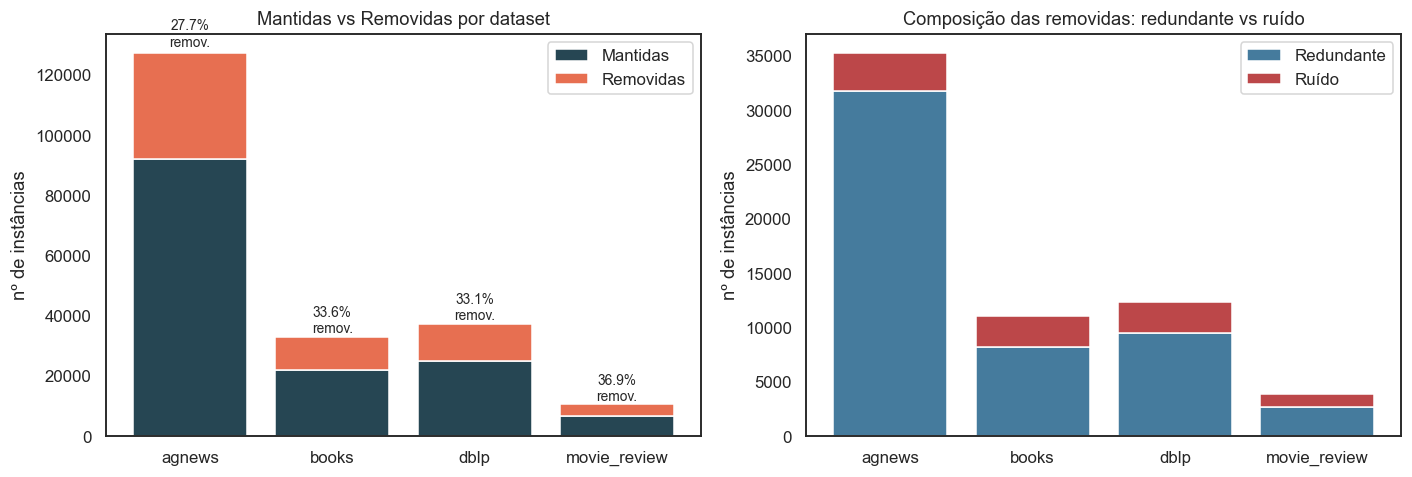

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) mantidas vs removidas (stacked)
ax = axes[0]
ax.bar(overview.index, overview["mantidas"], label="Mantidas", color="#264653")
ax.bar(overview.index, overview["removidas"], bottom=overview["mantidas"],
       label="Removidas", color="#e76f51")
for i, ds in enumerate(overview.index):
    tot = overview.loc[ds, "total"]
    rem = overview.loc[ds, "removidas"]
    ax.text(i, tot + tot*0.01, f"{rem/tot*100:.1f}%\nremov.", ha="center", va="bottom", fontsize=9)
ax.set_title("Mantidas vs Removidas por dataset")
ax.set_ylabel("nº de instâncias")
ax.legend()

# (b) decomposicao das removidas: redundante vs ruido
ax = axes[1]
ax.bar(overview.index, overview["removidas_redundante"], label="Redundante", color="#457b9d")
ax.bar(overview.index, overview["removidas_ruido"], bottom=overview["removidas_redundante"],
       label="Ruído", color="#bc4749")
ax.set_title("Composição das removidas: redundante vs ruído")
ax.set_ylabel("nº de instâncias")
ax.legend()

plt.tight_layout(); plt.show()


## 3. Análise 1 — Removidas: classificadas corretamente vs erroneamente

Para cada instância removida comparamos a anotação consensual dos modelos (`resolved_annotation`) com o rótulo verdadeiro (`ground_truth`):

- **Correta**: `resolved_annotation == ground_truth`
- **Errada**: `resolved_annotation != ground_truth`

Isso nos diz se o filtro está descartando majoritariamente dados que os LLMs **erraram** (limpeza desejável) ou dados que eles **acertaram** (potencial perda de sinal — esperado para as redundantes).

In [24]:
corr = (removed.groupby("dataset")["is_correct"]
        .agg(n="count", corretas="sum"))
corr["erradas"] = corr["n"] - corr["corretas"]
corr["%_corretas"] = (corr["corretas"] / corr["n"] * 100).round(1)
corr["%_erradas"]  = (corr["erradas"] / corr["n"] * 100).round(1)
corr = corr.reindex(DATASETS)
corr


,n,corretas,erradas,%_corretas,%_erradas
dataset,,,,,
agnews,35285,30202,5083,85.6,14.4
books,11089,7843,3246,70.7,29.3
dblp,12339,7796,4543,63.2,36.8
movie_review,3936,3536,400,89.8,10.2


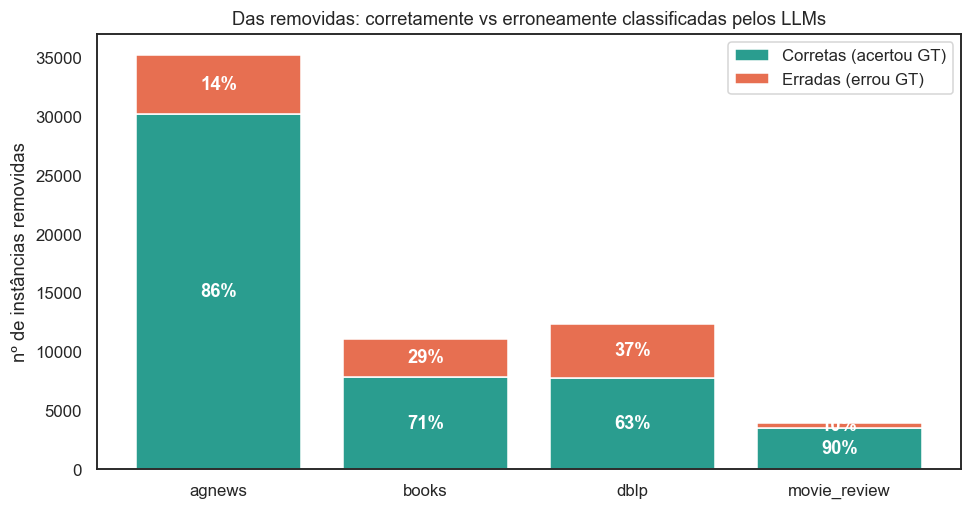

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(DATASETS))
corretas = corr["corretas"].values
erradas  = corr["erradas"].values
ax.bar(x, corretas, label="Corretas (acertou GT)", color="#2a9d8f")
ax.bar(x, erradas, bottom=corretas, label="Erradas (errou GT)", color="#e76f51")
for i in range(len(DATASETS)):
    tot = corretas[i] + erradas[i]
    ax.text(i, corretas[i]/2, f"{corretas[i]/tot*100:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(i, corretas[i] + erradas[i]/2, f"{erradas[i]/tot*100:.0f}%", ha="center", va="center", color="white", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(DATASETS)
ax.set_ylabel("nº de instâncias removidas")
ax.set_title("Das removidas: corretamente vs erroneamente classificadas pelos LLMs")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Análise 2 — Removidas por nível de consenso

`high` = 3x0 (alto consenso / unânime) vs `medium` = 2x1 (baixo consenso / maioria simples). _(O nível 1x1x1 foi excluído na carga.)_

In [26]:
cons = (removed.groupby(["dataset", "consensus_level"]).size()
        .unstack(fill_value=0).reindex(index=DATASETS, columns=CONSENSUS_ORDER, fill_value=0))
cons_pct = cons.div(cons.sum(axis=1), axis=0) * 100
print("Contagem absoluta:"); display(cons.rename(columns=CONSENSUS_LABELS))
print("Percentual por dataset (%):"); display(cons_pct.round(1).rename(columns=CONSENSUS_LABELS))

# agrupamento alto vs baixo consenso
resumo_cons = pd.DataFrame({
    "alto_consenso_3x0": cons["high"],
    "baixo_consenso_2x1": cons["medium"],
})
resumo_cons["%_alto"] = (resumo_cons["alto_consenso_3x0"] / resumo_cons.sum(axis=1) * 100).round(1)
resumo_cons


Contagem absoluta:


consensus_level,Alto (3x0),Baixo (2x1)
dataset,,
agnews,31499,3786
books,8054,3035
dblp,8739,3600
movie_review,3480,456


Percentual por dataset (%):


consensus_level,Alto (3x0),Baixo (2x1)
dataset,,
agnews,89.3,10.7
books,72.6,27.4
dblp,70.8,29.2
movie_review,88.4,11.6


,alto_consenso_3x0,baixo_consenso_2x1,%_alto
dataset,,,
agnews,31499,3786,89.3
books,8054,3035,72.6
dblp,8739,3600,70.8
movie_review,3480,456,88.4


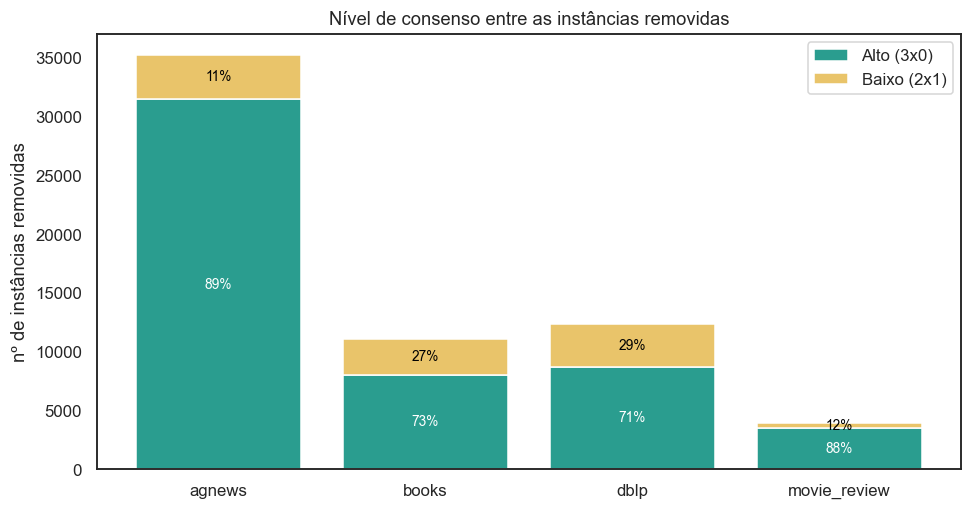

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(DATASETS))
for lvl in CONSENSUS_ORDER:
    vals = cons[lvl].values
    ax.bar(DATASETS, vals, bottom=bottom, label=CONSENSUS_LABELS[lvl], color=PALETTE[lvl])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(i, bottom[i] + v/2, f"{v/cons.sum(axis=1).values[i]*100:.0f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if lvl != "medium" else "black")
    bottom += vals
ax.set_ylabel("nº de instâncias removidas")
ax.set_title("Nível de consenso entre as instâncias removidas")
ax.legend(); plt.tight_layout(); plt.show()


## 5. Cruzamento — Corretude × Nível de consenso

Hipótese: instâncias de **baixo consenso** (2x1) concentram a maior parte dos **erros** dos modelos, enquanto as de **alto consenso** removidas tendem a ser corretas (redundância).

In [28]:
# tabela: taxa de erro por nivel de consenso, por dataset
err_by_cons = (removed.groupby(["dataset", "consensus_level"])["is_correct"]
               .agg(n="count", erro=lambda s: (~s).mean()))
err_by_cons["%_erro"] = (err_by_cons["erro"] * 100).round(1)
err_by_cons = err_by_cons.drop(columns="erro").reindex(
    pd.MultiIndex.from_product([DATASETS, CONSENSUS_ORDER], names=["dataset", "consensus_level"])
).dropna(how="all")
err_by_cons = err_by_cons.rename(index=CONSENSUS_LABELS)
err_by_cons.index = err_by_cons.index.set_names(["dataset", "consenso"])
err_by_cons


n  %_erro
dataset      consenso                  
agnews       Alto (3x0)   31499    10.4
             Baixo (2x1)   3786    48.1
books        Alto (3x0)    8054    21.5
             Baixo (2x1)   3035    50.0
dblp         Alto (3x0)    8739    27.1
             Baixo (2x1)   3600    60.4
movie_review Alto (3x0)    3480     6.2
             Baixo (2x1)    456    40.6

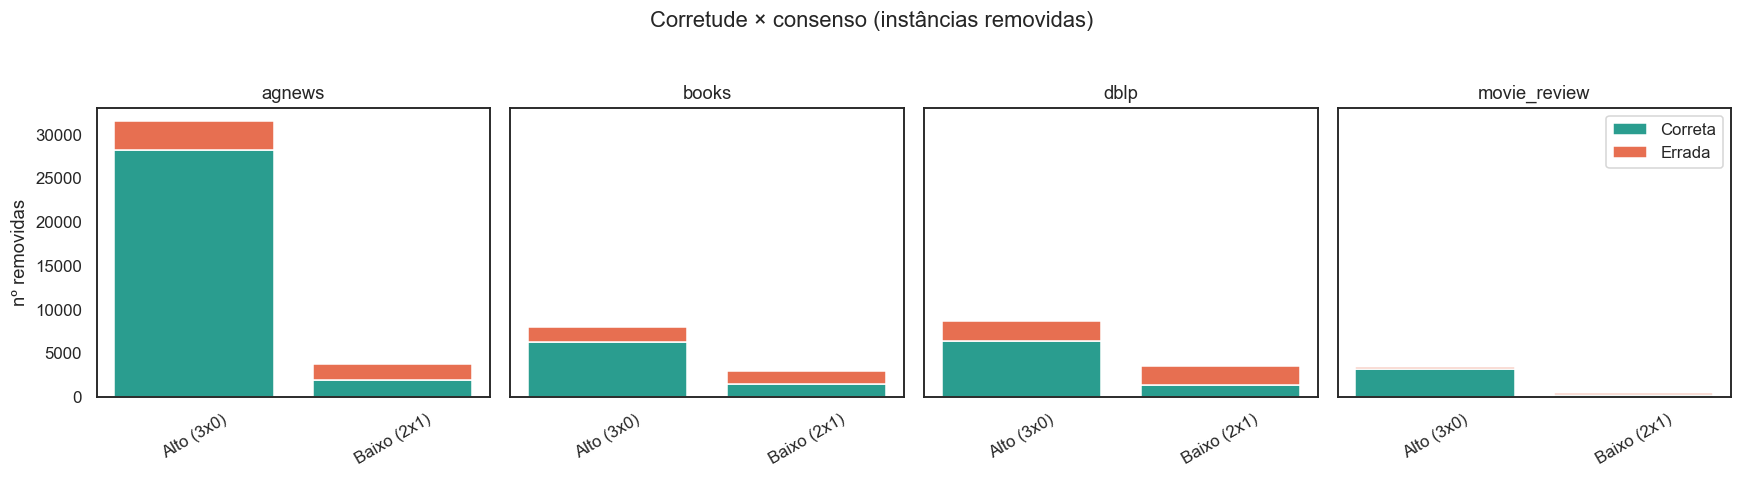

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharey=True)
for ax, ds in zip(axes, DATASETS):
    sub = removed[removed["dataset"] == ds]
    grp = (sub.groupby(["consensus_level", "is_correct"]).size()
           .unstack(fill_value=0).reindex(index=CONSENSUS_ORDER, fill_value=0))
    correct_col = grp.get(True, pd.Series(0, index=grp.index))
    wrong_col   = grp.get(False, pd.Series(0, index=grp.index))
    labels = [CONSENSUS_LABELS[l] for l in grp.index]
    ax.bar(labels, correct_col, label="Correta", color="#2a9d8f")
    ax.bar(labels, wrong_col, bottom=correct_col, label="Errada", color="#e76f51")
    ax.set_title(ds); ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("nº removidas")
axes[-1].legend(loc="upper right")
plt.suptitle("Corretude × consenso (instâncias removidas)", y=1.03)
plt.tight_layout(); plt.show()


## 6. Cruzamento — Corretude × Motivo de remoção (redundante vs ruído)

O bio-IS classifica cada remoção como **redundante** (bem representada por vizinhos da mesma classe) ou **ruído** (atípica / provável erro). Esperamos que a fatia **ruído** concentre os erros de anotação.

n  %_erro
dataset      motivo                   
agnews       Ruído        3458    52.3
             Redundante  31827    10.3
books        Ruído        2838    48.3
             Redundante   8251    22.7
dblp         Ruído        2876    65.2
             Redundante   9463    28.2
movie_review Ruído        1273    20.0
             Redundante   2663     5.4

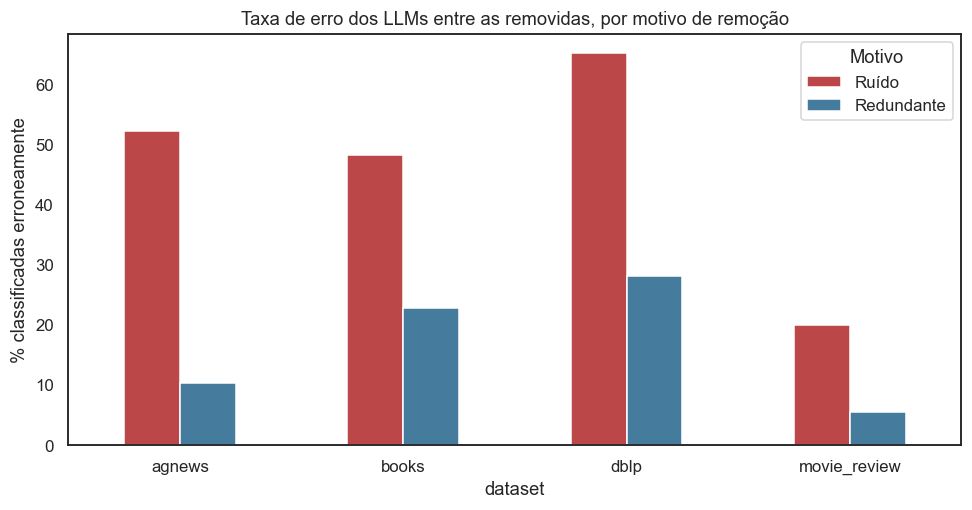

In [30]:
reason = (removed.groupby(["dataset", "removal_reason"])["is_correct"]
          .agg(n="count", erro=lambda s: (~s).mean()))
reason["%_erro"] = (reason["erro"] * 100).round(1)
reason = reason.drop(columns="erro")
reason = reason.rename(index={"redundant": "Redundante", "noise": "Ruído"})
reason.index = reason.index.set_names(["dataset", "motivo"])
display(reason)

fig, ax = plt.subplots(figsize=(9, 4.8))
piv = (removed.groupby(["dataset", "removal_reason"])["is_correct"]
       .apply(lambda s: (~s).mean()*100).unstack().reindex(DATASETS)
       .rename(columns={"redundant": "Redundante", "noise": "Ruído"}))
piv.columns.name = "Motivo"
piv.plot(kind="bar", ax=ax, color={"Redundante": "#457b9d", "Ruído": "#bc4749"})
ax.set_ylabel("% classificadas erroneamente")
ax.set_title("Taxa de erro dos LLMs entre as removidas, por motivo de remoção")
ax.legend(title="Motivo"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 7. Validação da qualidade do filtro — Removidas vs Mantidas

A pergunta central de qualidade: **o Instance Selection está concentrando os erros de anotação nas instâncias que descarta?** Se sim, a taxa de erro dos LLMs deve ser bem maior nas removidas do que nas mantidas.

Também calculamos o **recall de erros**: do total de instâncias mal anotadas (no universo considerado), que fração foi removida pelo filtro.

In [31]:
rows = []
for ds in DATASETS:
    rem, kep = removed_all[ds], kept_all[ds]
    err_rem = (~rem["is_correct"]).sum()
    err_kep = (~kep["is_correct"]).sum()
    total_err = err_rem + err_kep
    rows.append({
        "dataset": ds,
        "acc_removidas": rem["is_correct"].mean(),
        "acc_mantidas": kep["is_correct"].mean(),
        "erro_removidas_%": (~rem["is_correct"]).mean()*100,
        "erro_mantidas_%": (~kep["is_correct"]).mean()*100,
        "recall_erros_%": (err_rem / total_err * 100) if total_err else np.nan,
        "n_erros_total": total_err,
    })
quality = pd.DataFrame(rows).set_index("dataset").round(3)
quality


,acc_removidas,acc_mantidas,erro_removidas_%,erro_mantidas_%,recall_erros_%,n_erros_total
dataset,,,,,,
agnews,0.856,0.872,14.406,12.788,30.164,16851
books,0.707,0.732,29.272,26.825,35.573,9125
dblp,0.632,0.652,36.818,34.760,34.422,13198
movie_review,0.898,0.922,10.163,7.756,43.431,921


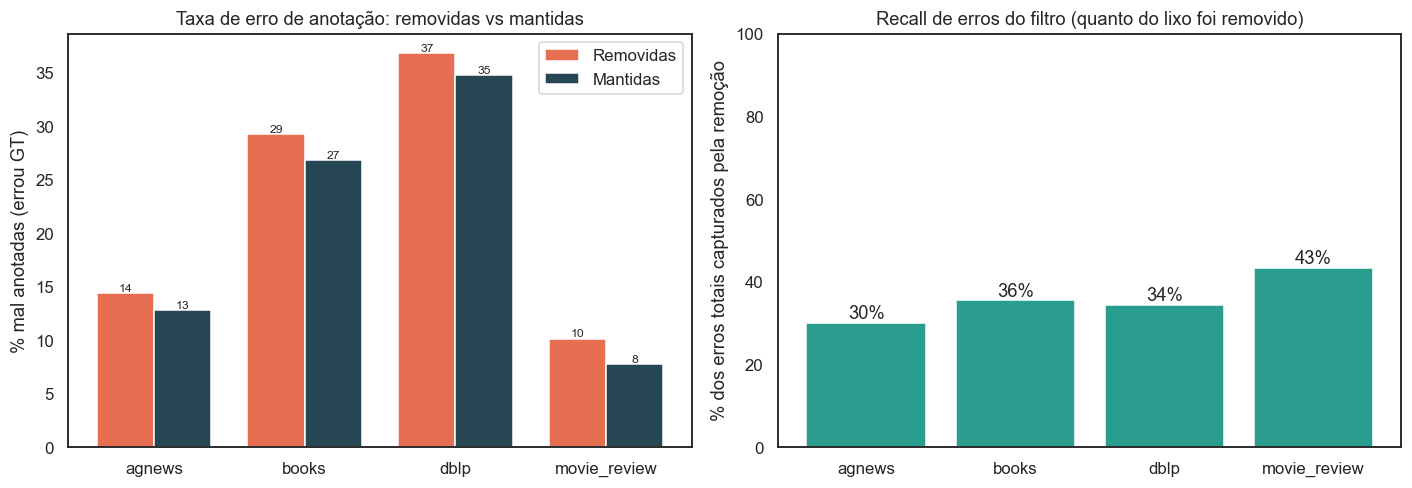

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) taxa de erro: removidas vs mantidas
ax = axes[0]
x = np.arange(len(DATASETS)); w = 0.38
ax.bar(x - w/2, quality["erro_removidas_%"], w, label="Removidas", color="#e76f51")
ax.bar(x + w/2, quality["erro_mantidas_%"], w, label="Mantidas", color="#264653")
ax.set_xticks(x); ax.set_xticklabels(DATASETS)
ax.set_ylabel("% mal anotadas (errou GT)")
ax.set_title("Taxa de erro de anotação: removidas vs mantidas")
ax.legend()
for i in range(len(DATASETS)):
    ax.text(i - w/2, quality["erro_removidas_%"].iloc[i], f"{quality['erro_removidas_%'].iloc[i]:.0f}",
            ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, quality["erro_mantidas_%"].iloc[i], f"{quality['erro_mantidas_%'].iloc[i]:.0f}",
            ha="center", va="bottom", fontsize=8)

# (b) recall de erros
ax = axes[1]
ax.bar(DATASETS, quality["recall_erros_%"], color="#e76f51")
for i, v in enumerate(quality["recall_erros_%"]):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom")
ax.set_ylabel("% dos erros totais capturados pela remoção")
ax.set_title("Recall de erros do filtro (quanto do lixo foi removido)")
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()


## 8. Distribuição das removidas por classe

Verifica se a remoção é equilibrada entre classes ou se penaliza desproporcionalmente alguma categoria (o que pode introduzir viés no dataset filtrado).

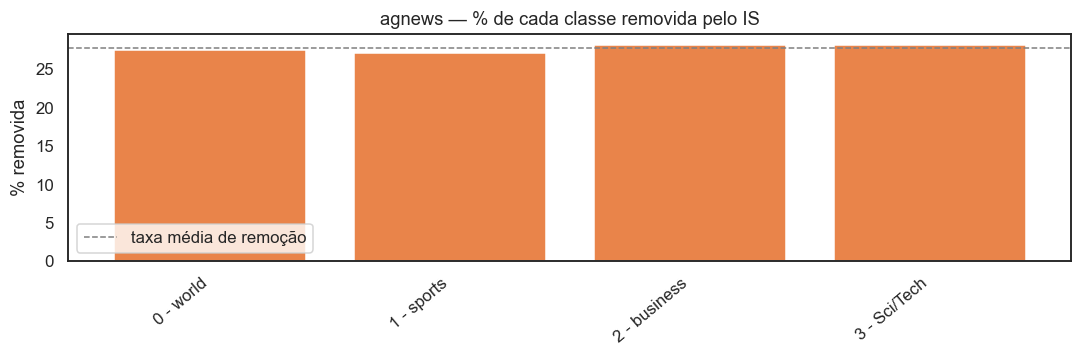

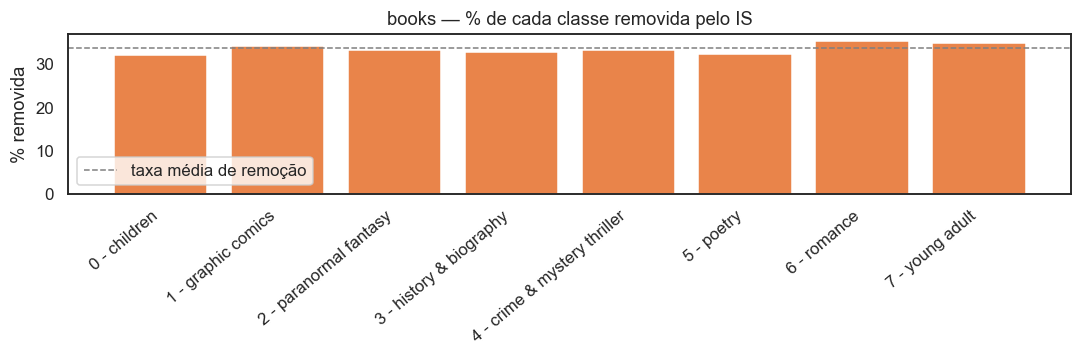

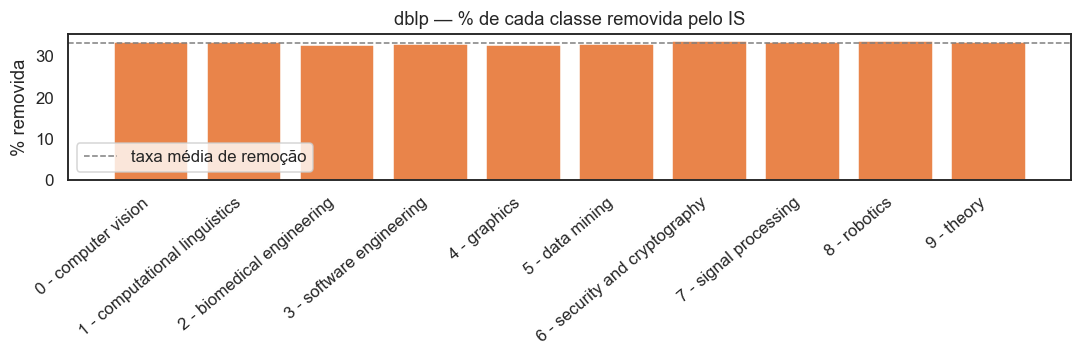

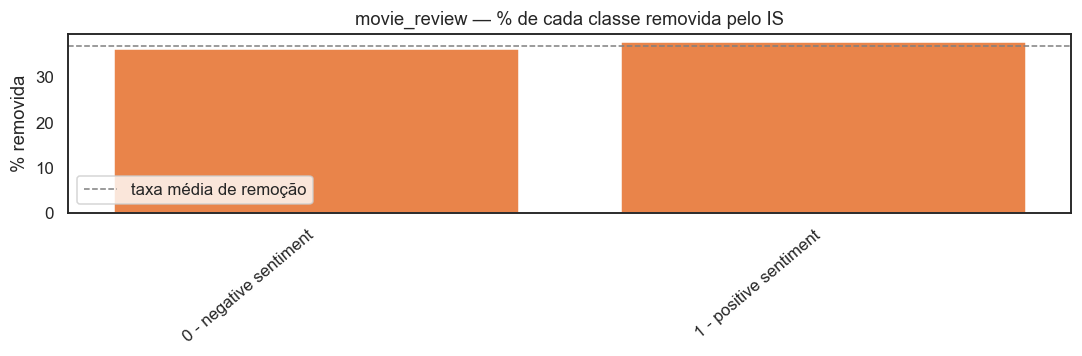

In [33]:
for ds in DATASETS:
    rem, kep = removed_all[ds], kept_all[ds]
    classes = sorted(pd.concat([rem["ground_truth"], kep["ground_truth"]]).unique())
    rem_c = rem["ground_truth"].value_counts().reindex(classes, fill_value=0)
    tot_c = (rem["ground_truth"].value_counts().reindex(classes, fill_value=0)
             + kep["ground_truth"].value_counts().reindex(classes, fill_value=0))
    pct = (rem_c / tot_c * 100)

    fig, ax = plt.subplots(figsize=(10, 3.4))
    names = [label_name(ds, c) for c in classes]
    ax.bar(names, pct.values, color="#e9844a")
    ax.axhline(len(rem)/(len(rem)+len(kep))*100, color="gray", ls="--", lw=1,
               label="taxa média de remoção")
    ax.set_ylabel("% removida")
    ax.set_title(f"{ds} — % de cada classe removida pelo IS")
    ax.tick_params(axis="x", rotation=40)
    for lab in ax.get_xticklabels(): lab.set_ha("right")
    ax.legend(); plt.tight_layout(); plt.show()


## 9. Tamanho do texto e confiança — removidas vs mantidas

Duas heurísticas extras: textos muito curtos costumam ser mais ambíguos, e a **confiança média** dos modelos (`*_rep1_conf`) tende a ser menor em instâncias problemáticas.

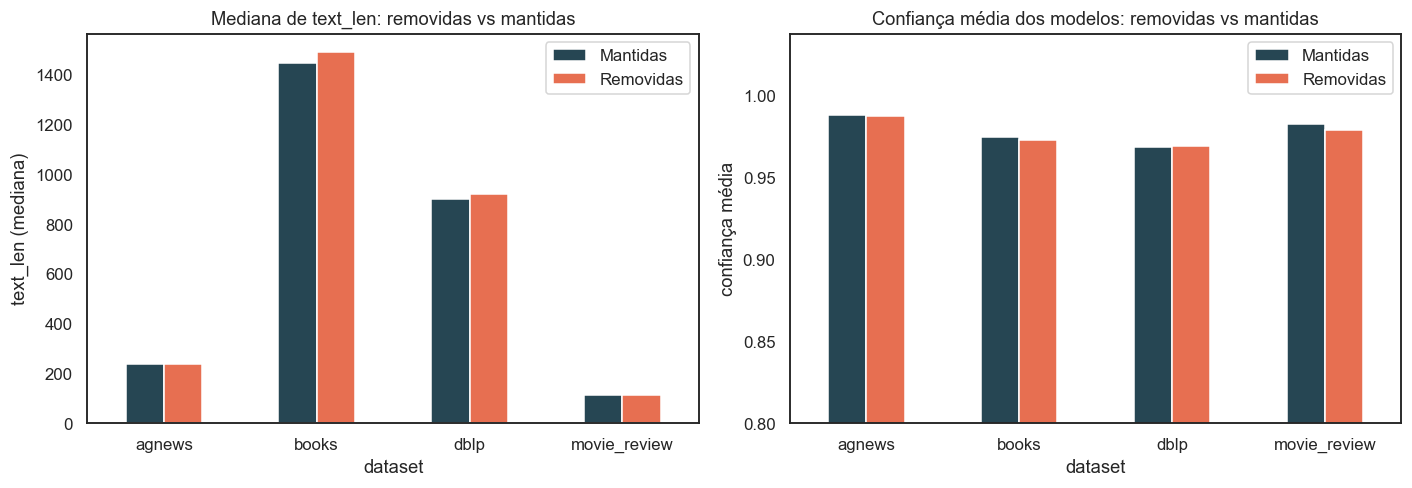

In [34]:
# confianca media dos 3 modelos por instancia
conf_cols = [c for c in both.columns if c.endswith("_rep1_conf")]
both["conf_media"] = both[conf_cols].mean(axis=1)

STATUS_PT = {"removed": "Removidas", "kept": "Mantidas"}
CORES_STATUS = {"Removidas": "#e76f51", "Mantidas": "#264653"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# text_len medio (mediana) removidas vs mantidas
tl = (both.groupby(["dataset", "status"])["text_len"].median()
      .unstack().reindex(DATASETS).rename(columns=STATUS_PT))
tl.columns.name = None
tl.plot(kind="bar", ax=axes[0], color=CORES_STATUS)
axes[0].set_title("Mediana de text_len: removidas vs mantidas")
axes[0].set_ylabel("text_len (mediana)")
axes[0].tick_params(axis="x", rotation=0)

# confianca media removidas vs mantidas
cf = (both.groupby(["dataset", "status"])["conf_media"].mean()
      .unstack().reindex(DATASETS).rename(columns=STATUS_PT))
cf.columns.name = None
cf.plot(kind="bar", ax=axes[1], color=CORES_STATUS)
axes[1].set_title("Confiança média dos modelos: removidas vs mantidas")
axes[1].set_ylabel("confiança média")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(bottom=min(0.8, cf.min().min()*0.98))

plt.tight_layout(); plt.show()


## 10. Síntese consolidada

Tabela única reunindo os principais indicadores por dataset.

In [35]:
sintese = pd.DataFrame({
    "removidas": overview["removidas"],
    "taxa_reducao_%": (overview["taxa_reducao"]*100).round(1),
    "%_remov_corretas": corr["%_corretas"],
    "%_remov_erradas": corr["%_erradas"],
    "%_alto_consenso(3x0)": resumo_cons["%_alto"],
    "erro_removidas_%": quality["erro_removidas_%"].round(1),
    "erro_mantidas_%": quality["erro_mantidas_%"].round(1),
    "recall_erros_%": quality["recall_erros_%"].round(1),
}).reindex(DATASETS)
sintese


,removidas,taxa_reducao_%,%_remov_corretas,%_remov_erradas,%_alto_consenso(3x0),erro_removidas_%,erro_mantidas_%,recall_erros_%
dataset,,,,,,,,
agnews,35285,27.7,85.6,14.4,89.3,14.4,12.8,30.2
books,11089,33.6,70.7,29.3,72.6,29.3,26.8,35.6
dblp,12339,33.1,63.2,36.8,70.8,36.8,34.8,34.4
movie_review,3936,36.9,89.8,10.2,88.4,10.2,7.8,43.4


### Como ler os resultados

- **`%_remov_erradas`** alto + **`erro_mantidas_%`** baixo ⇒ o filtro está cumprindo o papel de limpeza: descarta o que os LLMs erraram e mantém o que acertaram.
- **`recall_erros_%`** indica quanto do "lixo" (anotações erradas) total foi efetivamente removido.
- Parte das removidas será sempre **correta** — são as **redundantes** (alto consenso), descartadas por redundância e não por erro. Compare com a coluna de motivo de remoção da Seção 6.
- Cheque a Seção 8 para garantir que nenhuma classe está sendo removida de forma desproporcional (risco de viés no dataset filtrado).
- ⚠️ As instâncias 1x1x1 (discordância total) **não** entram nesta análise — são tratadas/removidas à parte como casos problemáticos.
